In [36]:
# =============================================
# MASTER CELL — RUN THIS FIRST EVERY TIME
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

FILE_PATH = r'C:\Users\shail\Downloads\covid_19_dataset-1718175635.xlsx'

# ---- Helper function to fix column names ----
def fix_columns(df):
    fixed = []
    for col in df.columns:
        if isinstance(col, str):
            fixed.append(col)
        elif hasattr(col, 'strftime'):
            fixed.append(f"{col.day}/{col.month}/{str(col.year)[2:]}")
        else:
            fixed.append(str(col))
    df.columns = fixed
    return df

# ---- Load all 3 datasets ----
confirmed = pd.read_excel(FILE_PATH, sheet_name='covid_19_confirmed_v1')
deaths    = pd.read_excel(FILE_PATH, sheet_name='covid_19_deaths_v1')
recovered = pd.read_excel(FILE_PATH, sheet_name='covid_19_recovered_v1')

# ---- Fix column names ----
confirmed = fix_columns(confirmed)
deaths    = fix_columns(deaths)
recovered = fix_columns(recovered)

# ---- Handle Missing Data ----
confirmed_dates = confirmed.columns[4:]
deaths_dates    = deaths.columns[4:]
recovered_dates = recovered.columns[4:]

confirmed[confirmed_dates] = confirmed[confirmed_dates].ffill(axis=1).bfill(axis=1)
deaths[deaths_dates]       = deaths[deaths_dates].ffill(axis=1).bfill(axis=1)
recovered[recovered_dates] = recovered[recovered_dates].ffill(axis=1).bfill(axis=1)

confirmed.fillna(0, inplace=True)
deaths.fillna(0, inplace=True)
recovered.fillna(0, inplace=True)

# ---- Data Cleaning ----
confirmed['Province/State'] = confirmed['Province/State'].replace(0, 'All Provinces').fillna('All Provinces')
deaths['Province/State']    = deaths['Province/State'].replace(0, 'All Provinces').fillna('All Provinces')
recovered['Province/State'] = recovered['Province/State'].replace(0, 'All Provinces').fillna('All Provinces')

# ---- Build deaths_long (Wide to Long) ----
deaths_raw = pd.read_excel(FILE_PATH, sheet_name='covid_19_deaths_v1', header=None)
raw_columns = deaths_raw.iloc[0].tolist()

fixed_columns = []
for col in raw_columns:
    if isinstance(col, str):
        fixed_columns.append(col)
    elif hasattr(col, 'strftime'):
        fixed_columns.append(f"{col.day}/{col.month}/{str(col.year)[2:]}")
    else:
        fixed_columns.append(str(col))

deaths_raw.columns = fixed_columns
deaths_raw = deaths_raw.iloc[1:].reset_index(drop=True)

info_cols = ['Province/State', 'Country/Region', 'Lat', 'Long']
date_cols = fixed_columns[4:]

deaths_long = deaths_raw.melt(
    id_vars=info_cols,
    value_vars=date_cols,
    var_name='Date',
    value_name='Deaths'
)

deaths_long['Date']           = pd.to_datetime(deaths_long['Date'], format='%m/%d/%y')
deaths_long['Province/State'] = deaths_long['Province/State'].fillna('All Provinces')
deaths_long['Deaths']         = pd.to_numeric(deaths_long['Deaths'], errors='coerce').fillna(0)
deaths_long                   = deaths_long.sort_values(['Country/Region', 'Date']).reset_index(drop=True)

# ---- Done ----
print("✅ confirmed  :", confirmed.shape)
print("✅ deaths     :", deaths.shape)
print("✅ recovered  :", recovered.shape)
print("✅ deaths_long:", deaths_long.shape)
print("\n📅 deaths_long date range:")
print("   Start:", deaths_long['Date'].min().date())
print("   End  :", deaths_long['Date'].max().date())
print("\n🚀 All variables ready!")

✅ confirmed  : (276, 498)
✅ deaths     : (276, 498)
✅ recovered  : (261, 498)
✅ deaths_long: (136344, 6)

📅 deaths_long date range:
   Start: 2020-01-22
   End  : 2021-05-29

🚀 All variables ready!


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load all 3 sheets
confirmed = pd.read_excel(r'C:\Users\shail\Downloads\covid_19_dataset-1718175635.xlsx', 
                          sheet_name='covid_19_confirmed_v1')
deaths = pd.read_excel(r'C:\Users\shail\Downloads\covid_19_dataset-1718175635.xlsx', 
                       sheet_name='covid_19_deaths_v1')
recovered = pd.read_excel(r'C:\Users\shail\Downloads\covid_19_dataset-1718175635.xlsx', 
                          sheet_name='covid_19_recovered_v1')

# Fix column names 
def fix_columns(df):
    new_cols = []
    for col in df.columns:
        if isinstance(col, str):
            new_cols.append(col)
        else:
            # Windows-safe datetime to string conversion
            new_cols.append(f"{col.month}/{col.day}/{str(col.year)[2:]}")
    df.columns = new_cols
    return df

# Apply fix to all 3 datasets

confirmed = fix_columns(confirmed)
deaths = fix_columns(deaths)
recovered = fix_columns(recovered)

print("✅ Confirmed Cases loaded:", confirmed.shape)
print("✅ Deaths loaded:", deaths.shape)
print("✅ Recovered loaded:", recovered.shape)
print("\nFirst 8 column names:", list(confirmed.columns[:8]))

✅ Confirmed Cases loaded: (276, 498)
✅ Deaths loaded: (276, 498)
✅ Recovered loaded: (261, 498)

First 8 column names: ['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20', '1/24/20', '1/25/20']


In [38]:
# QUESTION 2.1 — DATA EXPLORATION (Structure) 

print("=" * 50)
print("CONFIRMED CASES DATASET")
print("=" * 50)
print("Shape:", confirmed.shape)
print("\nFirst 2 rows:")
confirmed.head(2)

CONFIRMED CASES DATASET
Shape: (276, 498)

First 2 rows:


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,64575,65080,65486,65728,66275,66903,67743,68366,69130,70111
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,132118,132153,132176,132209,132215,132229,132244,132264,132285,132297


In [39]:
print("Data Types (first 6 columns):")
print(confirmed.dtypes[:6])
print("\nBasic Info:")
confirmed.info(verbose=False)

Data Types (first 6 columns):
Province/State     object
Country/Region     object
Lat               float64
Long              float64
1/22/20             int64
1/23/20             int64
dtype: object

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Columns: 498 entries, Province/State to 5/29/21
dtypes: float64(2), int64(494), object(2)
memory usage: 1.0+ MB


In [40]:
print("Shape:", deaths.shape)
deaths.head(2)

Shape: (276, 498)


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,2772,2782,2792,2802,2812,2836,2855,2869,2881,2899
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,2440,2441,2442,2444,2445,2447,2447,2447,2448,2449


In [41]:
print("Shape:", recovered.shape)
recovered.head(2)

Shape: (261, 498)


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,55687,55790,55889,56035,56295,56518,56711,56962,57119,57281
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,127869,128425,128601,128732,128826,128907,128978,129042,129097,129215


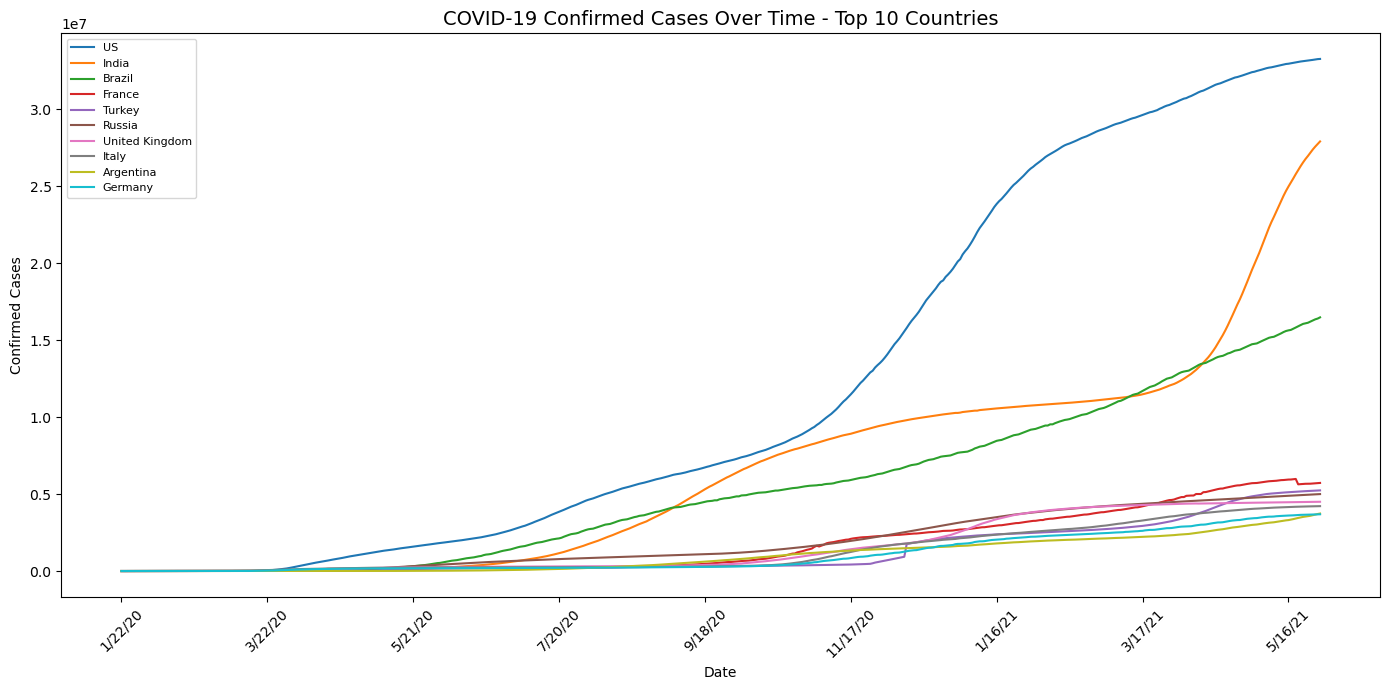

In [42]:
date_columns = confirmed.columns[4:]

confirmed_grouped = confirmed.groupby('Country/Region')[date_columns].sum()

top_countries = confirmed_grouped[date_columns[-1]].nlargest(10).index

plt.figure(figsize=(14, 7))

for country in top_countries:
    plt.plot(date_columns, confirmed_grouped.loc[country], label=country)

plt.title('COVID-19 Confirmed Cases Over Time - Top 10 Countries', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.legend(loc='upper left', fontsize=8)
plt.xticks(date_columns[::60], rotation=45)
plt.tight_layout()
plt.show()

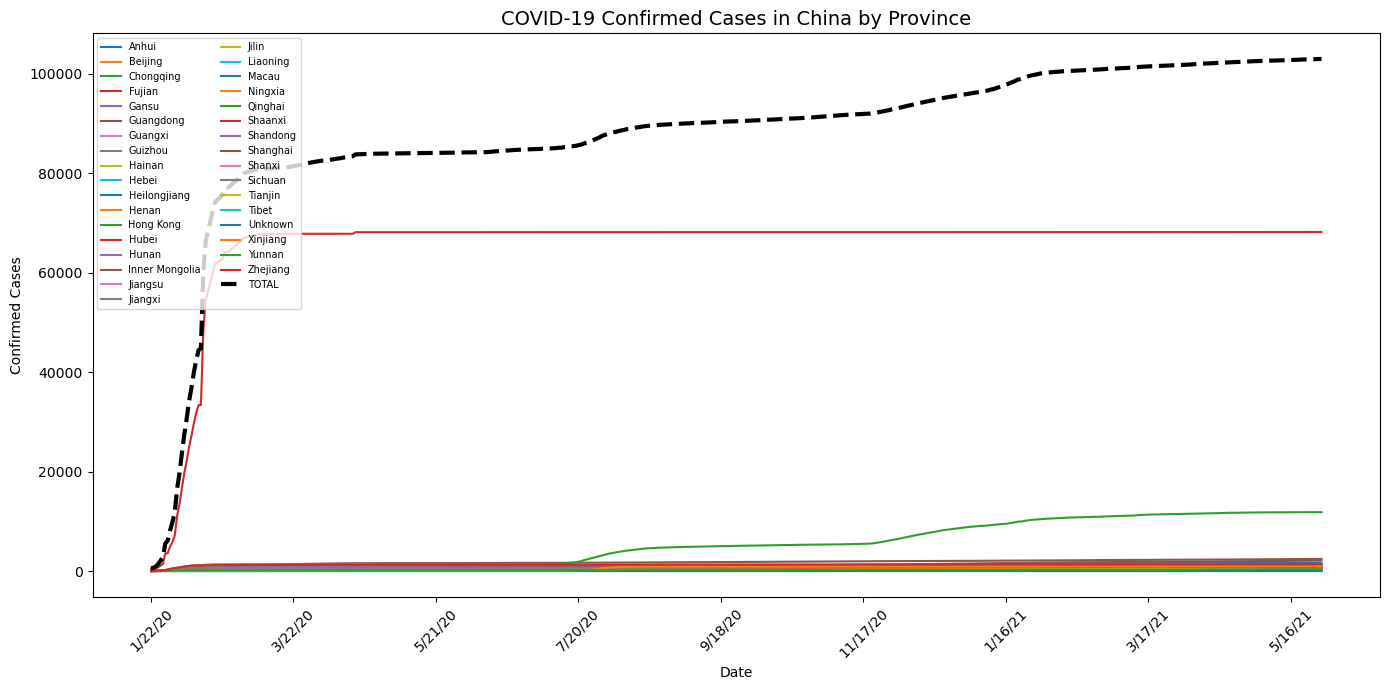

In [43]:
# =============================================
# QUESTION 2.3 — CONFIRMED CASES FOR CHINA
# =============================================

# Step 1: Filter only China rows
china_data = confirmed[confirmed['Country/Region'] == 'China']

# Step 2: Get date columns
date_columns = confirmed.columns[4:]

# Step 3: Plot each province as a separate line
plt.figure(figsize=(14, 7))

for _, row in china_data.iterrows():
    province = row['Province/State']
    plt.plot(date_columns, row[date_columns], label=province)

# Step 4: Also plot China total
china_total = china_data[date_columns].sum()
plt.plot(date_columns, china_total, label='TOTAL', 
         color='black', linewidth=3, linestyle='--')

# Step 5: Formatting
plt.title('COVID-19 Confirmed Cases in China by Province', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.legend(loc='upper left', fontsize=7, ncol=2)
plt.xticks(date_columns[::60], rotation=45)
plt.tight_layout()
plt.show()

In [44]:
# =============================================
# QUESTION 3 — HANDLING MISSING DATA
# =============================================

# Step 1: Check missing values BEFORE filling
print("Missing Values BEFORE filling:")
print("-" * 40)
print("Confirmed:", confirmed.isnull().sum().sum())
print("Deaths:   ", deaths.isnull().sum().sum())
print("Recovered:", recovered.isnull().sum().sum())

# Step 2: Get date columns
date_columns = confirmed.columns[4:]

# Step 3: Apply forward fill on date columns only
confirmed[date_columns] = confirmed[date_columns].ffill(axis=1)
deaths[date_columns] = deaths[date_columns].ffill(axis=1)
recovered[recovered.columns[4:]] = recovered[recovered.columns[4:]].ffill(axis=1)

# Step 4: Check missing values AFTER filling
print("\nMissing Values AFTER filling:")
print("-" * 40)
print("Confirmed:", confirmed.isnull().sum().sum())
print("Deaths:   ", deaths.isnull().sum().sum())
print("Recovered:", recovered.isnull().sum().sum())

print("\n✅ Missing data handled successfully!")

Missing Values BEFORE filling:
----------------------------------------
Confirmed: 194
Deaths:    195
Recovered: 194

Missing Values AFTER filling:
----------------------------------------
Confirmed: 194
Deaths:    194
Recovered: 193

✅ Missing data handled successfully!


In [45]:
# =============================================
# QUESTION 3 — HANDLING MISSING DATA (FIXED)
# =============================================

# Step 1: Check missing values BEFORE filling
print("Missing Values BEFORE filling:")
print("-" * 40)
print("Confirmed:", confirmed.isnull().sum().sum())
print("Deaths:   ", deaths.isnull().sum().sum())
print("Recovered:", recovered.isnull().sum().sum())

# Step 2: Get date columns for each dataset
confirmed_dates = confirmed.columns[4:]
deaths_dates = deaths.columns[4:]
recovered_dates = recovered.columns[4:]

# Step 3: Apply forward fill THEN backward fill
# Forward fill — copies value from previous day
# Backward fill — catches missing values at the START of the row
confirmed[confirmed_dates] = confirmed[confirmed_dates].ffill(axis=1).bfill(axis=1)
deaths[deaths_dates] = deaths[deaths_dates].ffill(axis=1).bfill(axis=1)
recovered[recovered_dates] = recovered[recovered_dates].ffill(axis=1).bfill(axis=1)

# Step 4: Fill any remaining with 0 (completely empty rows)
confirmed.fillna(0, inplace=True)
deaths.fillna(0, inplace=True)
recovered.fillna(0, inplace=True)

# Step 5: Check missing values AFTER filling
print("\nMissing Values AFTER filling:")
print("-" * 40)
print("Confirmed:", confirmed.isnull().sum().sum())
print("Deaths:   ", deaths.isnull().sum().sum())
print("Recovered:", recovered.isnull().sum().sum())

print("\n✅ Missing data handled successfully!")

Missing Values BEFORE filling:
----------------------------------------
Confirmed: 194
Deaths:    194
Recovered: 193

Missing Values AFTER filling:
----------------------------------------
Confirmed: 0
Deaths:    0
Recovered: 0

✅ Missing data handled successfully!


In [46]:
# =============================================
# QUESTION 4 — DATA CLEANING (FIXED)
# =============================================

# Step 1: Replace 0 AND blank values with "All Provinces"
# Using modern pandas syntax (no inplace warning)
confirmed['Province/State'] = confirmed['Province/State'].replace(0, 'All Provinces')
deaths['Province/State'] = deaths['Province/State'].replace(0, 'All Provinces')
recovered['Province/State'] = recovered['Province/State'].replace(0, 'All Provinces')

# Also handle any remaining NaN just in case
confirmed['Province/State'] = confirmed['Province/State'].fillna('All Provinces')
deaths['Province/State'] = deaths['Province/State'].fillna('All Provinces')
recovered['Province/State'] = recovered['Province/State'].fillna('All Provinces')

# Step 2: Verify the result
print("Sample Province/State values after cleaning:")
print("-" * 40)
print(confirmed[['Province/State', 'Country/Region']].head(10).to_string())

# Step 3: Check how many 'All Provinces' entries we have
print("\nTotal 'All Provinces' entries:")
print("Confirmed:", (confirmed['Province/State'] == 'All Provinces').sum())
print("Deaths:   ", (deaths['Province/State'] == 'All Provinces').sum())
print("Recovered:", (recovered['Province/State'] == 'All Provinces').sum())

print("\n✅ Data Cleaning Done!")

Sample Province/State values after cleaning:
----------------------------------------
                 Province/State       Country/Region
0                 All Provinces          Afghanistan
1                 All Provinces              Albania
2                 All Provinces              Algeria
3                 All Provinces              Andorra
4                 All Provinces               Angola
5                 All Provinces  Antigua and Barbuda
6                 All Provinces            Argentina
7                 All Provinces              Armenia
8  Australian Capital Territory            Australia
9               New South Wales            Australia

Total 'All Provinces' entries:
Confirmed: 190
Deaths:    190
Recovered: 191

✅ Data Cleaning Done!


Peak Single-Day New Cases:
Germany:
  Peak new cases in a single day : 49,044
  Date of peak                   : 12/30/20
---------------------------------------------
France:
  Peak new cases in a single day : 117,900
  Date of peak                   : 11/4/21
---------------------------------------------
Italy:
  Peak new cases in a single day : 40,902
  Date of peak                   : 11/13/20
---------------------------------------------


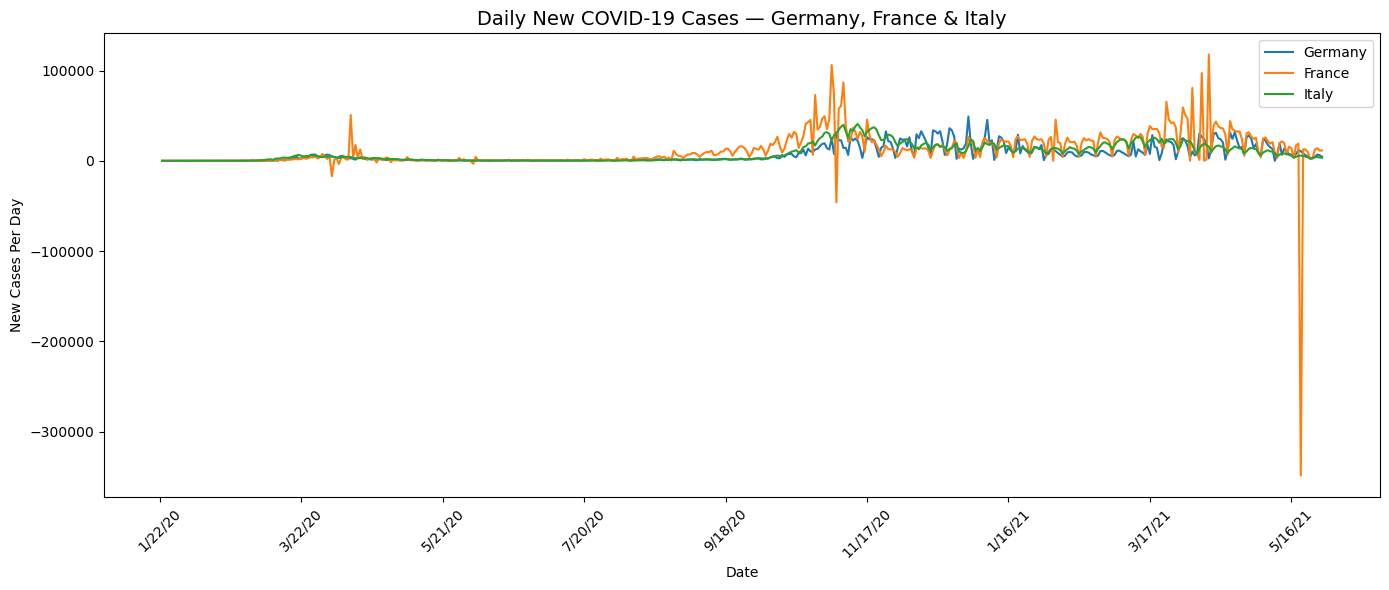

In [47]:
# =============================================
# QUESTION 5.1 — PEAK DAILY NEW CASES
#                Germany, France, Italy
# =============================================

# Step 1: Get date columns
date_columns = confirmed.columns[4:]

# Step 2: Filter each country and group
confirmed_grouped = confirmed.groupby('Country/Region')[date_columns].sum()

countries = ['Germany', 'France', 'Italy']

print("Peak Single-Day New Cases:")
print("=" * 45)

# Step 3: For each country find peak daily new cases
for country in countries:
    # Get cumulative cases for this country
    cumulative = confirmed_grouped.loc[country]
    
    # Calculate daily new cases (difference between consecutive days)
    daily_new = cumulative.diff()
    
    # Find the peak day
    peak_value = daily_new.max()
    peak_date = daily_new.idxmax()
    
    print(f"{country}:")
    print(f"  Peak new cases in a single day : {int(peak_value):,}")
    print(f"  Date of peak                   : {peak_date}")
    print("-" * 45)

# Step 4: Plot daily new cases for all 3 countries
plt.figure(figsize=(14, 6))

for country in countries:
    cumulative = confirmed_grouped.loc[country]
    daily_new = cumulative.diff()
    plt.plot(date_columns, daily_new, label=country, linewidth=1.5)

plt.title('Daily New COVID-19 Cases — Germany, France & Italy', fontsize=14)
plt.xlabel('Date')
plt.ylabel('New Cases Per Day')
plt.legend()
plt.xticks(date_columns[::60], rotation=45)
plt.tight_layout()
plt.show()

Recovery Rates as of December 31, 2020:

Canada:
  Confirmed Cases : 584,409
  Recovered Cases : 493,638
  Recovery Rate   : 84.47%
---------------------------------------------

Australia:
  Confirmed Cases : 28,425
  Recovered Cases : 22,565
  Recovery Rate   : 79.38%
---------------------------------------------


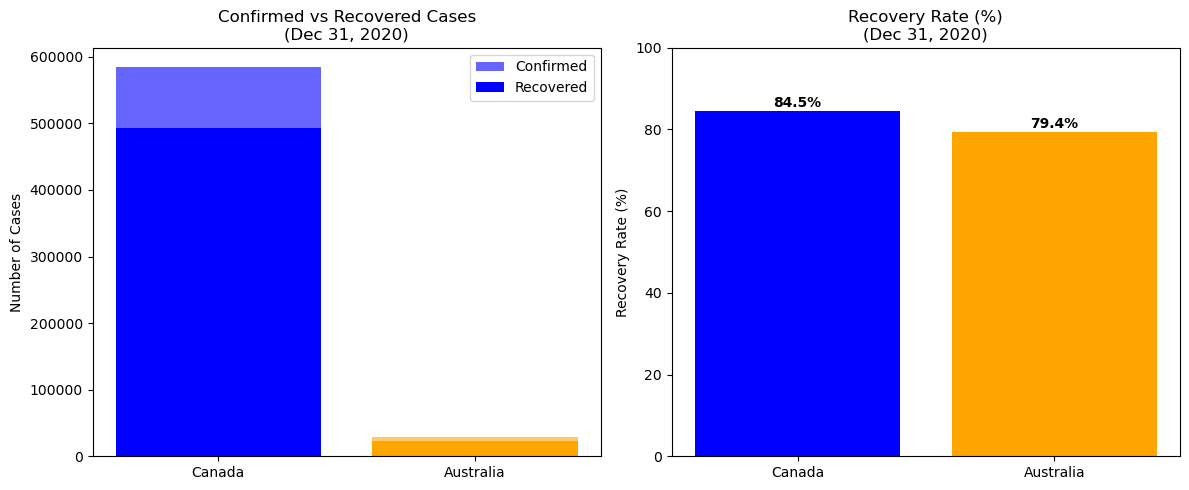

In [48]:
# =============================================
# QUESTION 5.2 — RECOVERY RATES
#                Canada vs Australia
#                As of Dec 31, 2020
# =============================================

# Step 1: Get date columns
date_columns = confirmed.columns[4:]
recovered_dates = recovered.columns[4:]

# Step 2: Group by country
confirmed_grouped = confirmed.groupby('Country/Region')[date_columns].sum()
recovered_grouped = recovered.groupby('Country/Region')[recovered_dates].sum()

# Step 3: Find the column for Dec 31, 2020
target_date = '12/31/20'

countries = ['Canada', 'Australia']

print("Recovery Rates as of December 31, 2020:")
print("=" * 45)

for country in countries:
    # Get confirmed and recovered cases on target date
    total_confirmed = confirmed_grouped.loc[country, target_date]
    total_recovered = recovered_grouped.loc[country, target_date]
    
    # Calculate recovery rate
    recovery_rate = (total_recovered / total_confirmed) * 100
    
    print(f"\n{country}:")
    print(f"  Confirmed Cases : {int(total_confirmed):,}")
    print(f"  Recovered Cases : {int(total_recovered):,}")
    print(f"  Recovery Rate   : {recovery_rate:.2f}%")
    print("-" * 45)

# Step 4: Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar 1 — Confirmed vs Recovered
x = ['Canada', 'Australia']
confirmed_vals = [confirmed_grouped.loc[c, target_date] for c in countries]
recovered_vals = [recovered_grouped.loc[c, target_date] for c in countries]

axes[0].bar(x, confirmed_vals, color=['blue', 'orange'], alpha=0.6, label='Confirmed')
axes[0].bar(x, recovered_vals, color=['blue', 'orange'], alpha=1.0, label='Recovered')
axes[0].set_title('Confirmed vs Recovered Cases\n(Dec 31, 2020)')
axes[0].set_ylabel('Number of Cases')
axes[0].legend()

# Bar 2 — Recovery Rate
recovery_rates = [(recovered_grouped.loc[c, target_date] / 
                   confirmed_grouped.loc[c, target_date]) * 100 
                   for c in countries]

axes[1].bar(x, recovery_rates, color=['blue', 'orange'])
axes[1].set_title('Recovery Rate (%)\n(Dec 31, 2020)')
axes[1].set_ylabel('Recovery Rate (%)')
axes[1].set_ylim(0, 100)

# Add percentage labels on bars
for i, v in enumerate(recovery_rates):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Death Rates by Province in Canada (Latest Data):
                 Province  Confirmed  Deaths  Death Rate (%)
                   Quebec     369728   11125            3.01
                    Yukon         84       2            2.38
                 Manitoba      50499    1045            2.07
            New Brunswick       2191      43            1.96
                  Ontario     537138    8698            1.62
              Nova Scotia       5530      84            1.52
         British Columbia     143581    1692            1.18
             Saskatchewan      46464     537            1.16
                  Alberta     226855    2214            0.98
                  Nunavut        648       4            0.62
Newfoundland and Labrador       1302       6            0.46
           Grand Princess         13       0            0.00
    Northwest Territories        127       0            0.00
     Prince Edward Island        200       0            0.00
   Repatriated Travellers         13

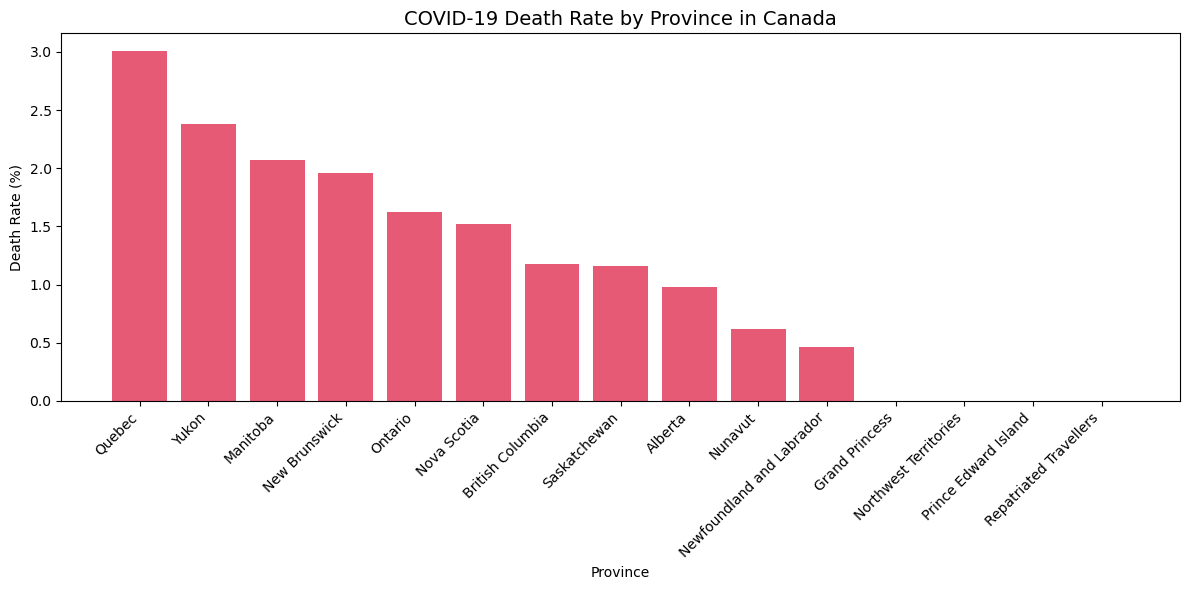

In [49]:
# =============================================
# QUESTION 5.3 — DEATH RATES BY PROVINCE
#                IN CANADA
# =============================================

# Step 1: Get date columns
date_columns = confirmed.columns[4:]
deaths_dates = deaths.columns[4:]

# Step 2: Filter Canada rows from confirmed and deaths
canada_confirmed = confirmed[confirmed['Country/Region'] == 'Canada']
canada_deaths = deaths[deaths['Country/Region'] == 'Canada']

# Step 3: Get the latest date (last column)
latest_date_confirmed = date_columns[-1]
latest_date_deaths = deaths_dates[-1]

# Step 4: Calculate death rate for each province
print("Death Rates by Province in Canada (Latest Data):")
print("=" * 55)

results = []

for province in canada_confirmed['Province/State'].unique():
    # Get confirmed cases for this province
    conf_row = canada_confirmed[canada_confirmed['Province/State'] == province]
    conf_cases = conf_row[latest_date_confirmed].values[0]
    
    # Get death cases for this province
    death_row = canada_deaths[canada_deaths['Province/State'] == province]
    
    if len(death_row) > 0 and conf_cases > 0:
        death_cases = death_row[latest_date_deaths].values[0]
        death_rate = (death_cases / conf_cases) * 100
        results.append({
            'Province': province,
            'Confirmed': int(conf_cases),
            'Deaths': int(death_cases),
            'Death Rate (%)': round(death_rate, 2)
        })

# Step 5: Convert to DataFrame and sort
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Death Rate (%)', ascending=False)

print(results_df.to_string(index=False))

# Step 6: Print highest and lowest
print("\n" + "=" * 55)
print(f"🔴 Highest Death Rate: {results_df.iloc[0]['Province']}"
      f" ({results_df.iloc[0]['Death Rate (%)']:.2f}%)")
print(f"🟢 Lowest Death Rate : {results_df.iloc[-1]['Province']}"
      f" ({results_df.iloc[-1]['Death Rate (%)']:.2f}%)")

# Step 7: Bar chart
plt.figure(figsize=(12, 6))
plt.bar(results_df['Province'], results_df['Death Rate (%)'], 
        color='crimson', alpha=0.7)
plt.title('COVID-19 Death Rate by Province in Canada', fontsize=14)
plt.xlabel('Province')
plt.ylabel('Death Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [50]:
# =============================================
# QUESTION 6.1 — FINAL FIX (Swap month/day)
# =============================================

import warnings
warnings.filterwarnings('ignore')

# Step 1: Reload raw
deaths_raw2 = pd.read_excel(r'C:\Users\shail\Downloads\covid_19_dataset-1718175635.xlsx', 
                            sheet_name='covid_19_deaths_v1',
                            header=None)

raw_columns = deaths_raw2.iloc[0].tolist()

# Step 2: Fix column names — swap month and day for datetime columns
fixed_columns = []
for col in raw_columns:
    if isinstance(col, str):
        fixed_columns.append(col)
    elif hasattr(col, 'strftime'):
        # Excel swapped month/day — so swap them back!
        # datetime(2020,1,2) actually means 2/1/20 (Feb 1) not Jan 2
        fixed_columns.append(f"{col.day}/{col.month}/{str(col.year)[2:]}")
    else:
        fixed_columns.append(str(col))

# Step 3: Assign fixed columns
deaths_raw2.columns = fixed_columns
deaths_raw2 = deaths_raw2.iloc[1:].reset_index(drop=True)

# Step 4: Verify columns look correct
print("First 20 fixed column names:")
print(fixed_columns[:20])

# Step 5: Melt to long format
info_cols = ['Province/State', 'Country/Region', 'Lat', 'Long']
date_cols = fixed_columns[4:]

deaths_long = deaths_raw2.melt(
    id_vars=info_cols,
    value_vars=date_cols,
    var_name='Date',
    value_name='Deaths'
)

# Step 6: Parse dates
deaths_long['Date'] = pd.to_datetime(deaths_long['Date'], format='%m/%d/%y')

# Step 7: Fix Province/State
deaths_long['Province/State'] = deaths_long['Province/State'].fillna('All Provinces')

# Step 8: Convert Deaths to numeric
deaths_long['Deaths'] = pd.to_numeric(deaths_long['Deaths'], errors='coerce').fillna(0)

# Step 9: Sort
deaths_long = deaths_long.sort_values(['Country/Region', 'Date']).reset_index(drop=True)

# Step 10: Preview
print("\nDeaths Dataset — Long Format (Final):")
print("=" * 50)
print("Shape:", deaths_long.shape)
print("\nFirst 10 rows:")
print(deaths_long.head(10).to_string(index=False))
print("\nDate Range:")
print("Start:", deaths_long['Date'].min())
print("End  :", deaths_long['Date'].max())
print("\nUnique dates:", deaths_long['Date'].nunique())

First 20 fixed column names:
['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20', '1/28/20', '1/29/20', '1/30/20', '1/31/20', '2/1/20', '2/2/20', '2/3/20', '2/4/20', '2/5/20', '2/6/20']

Deaths Dataset — Long Format (Final):
Shape: (136344, 6)

First 10 rows:
Province/State Country/Region       Lat       Long       Date  Deaths
 All Provinces    Afghanistan  33.93911  67.709953 2020-01-22     0.0
 All Provinces    Afghanistan  33.93911  67.709953 2020-01-23     0.0
 All Provinces    Afghanistan  33.93911  67.709953 2020-01-24     0.0
 All Provinces    Afghanistan  33.93911  67.709953 2020-01-25     0.0
 All Provinces    Afghanistan  33.93911  67.709953 2020-01-26     0.0
 All Provinces    Afghanistan  33.93911  67.709953 2020-01-27     0.0
 All Provinces    Afghanistan  33.93911  67.709953 2020-01-28     0.0
 All Provinces    Afghanistan  33.93911  67.709953 2020-01-29     0.0
 All Provinces    Afghanistan  33.93911  67.7

In [51]:
# Let's see exactly what the raw column names look like
deaths_raw2 = pd.read_excel(r'C:\Users\shail\Downloads\covid_19_dataset-1718175635.xlsx', 
                            sheet_name='covid_19_deaths_v1',
                            header=None)

raw_columns = deaths_raw2.iloc[0].tolist()

# Print first 20 column names with their types
print("First 20 column names and their types:")
print("=" * 50)
for i, col in enumerate(raw_columns[:20]):
    print(f"Col {i:2d}: value={col!r:30} type={type(col).__name__}")

First 20 column names and their types:
Col  0: value='Province/State'               type=str
Col  1: value='Country/Region'               type=str
Col  2: value='Lat'                          type=str
Col  3: value='Long'                         type=str
Col  4: value='1/22/20'                      type=str
Col  5: value='1/23/20'                      type=str
Col  6: value='1/24/20'                      type=str
Col  7: value='1/25/20'                      type=str
Col  8: value='1/26/20'                      type=str
Col  9: value='1/27/20'                      type=str
Col 10: value='1/28/20'                      type=str
Col 11: value='1/29/20'                      type=str
Col 12: value='1/30/20'                      type=str
Col 13: value='1/31/20'                      type=str
Col 14: value=datetime.datetime(2020, 1, 2, 0, 0) type=datetime
Col 15: value=datetime.datetime(2020, 2, 2, 0, 0) type=datetime
Col 16: value=datetime.datetime(2020, 3, 2, 0, 0) type=datetime
Col 17: value

In [52]:
# =============================================
# QUESTION 6.2 — TOTAL DEATHS PER COUNTRY
# =============================================

# Get the latest date for each country and sum provinces
total_deaths = deaths_long.groupby(['Country/Region', 'Date'])['Deaths'].sum().reset_index()

# Get the last date's value for each country (cumulative total)
latest_deaths = total_deaths.groupby('Country/Region')['Deaths'].last().reset_index()
latest_deaths.columns = ['Country/Region', 'Total Deaths']
latest_deaths = latest_deaths.sort_values('Total Deaths', ascending=False).reset_index(drop=True)

print("Total Deaths Per Country (Up to May 29, 2021):")
print("=" * 45)
print(latest_deaths.head(20).to_string(index=False))

Total Deaths Per Country (Up to May 29, 2021):
Country/Region  Total Deaths
            US      594306.0
        Brazil      461057.0
         India      325972.0
        Mexico      223455.0
United Kingdom      128037.0
         Italy      126002.0
        Russia      118781.0
        France      109518.0
       Germany       88413.0
      Colombia       87747.0
         Spain       79905.0
          Iran       79741.0
     Argentina       77108.0
        Poland       73682.0
          Peru       68978.0
  South Africa       56363.0
       Ukraine       52414.0
     Indonesia       50262.0
        Turkey       47271.0
       Romania       30247.0


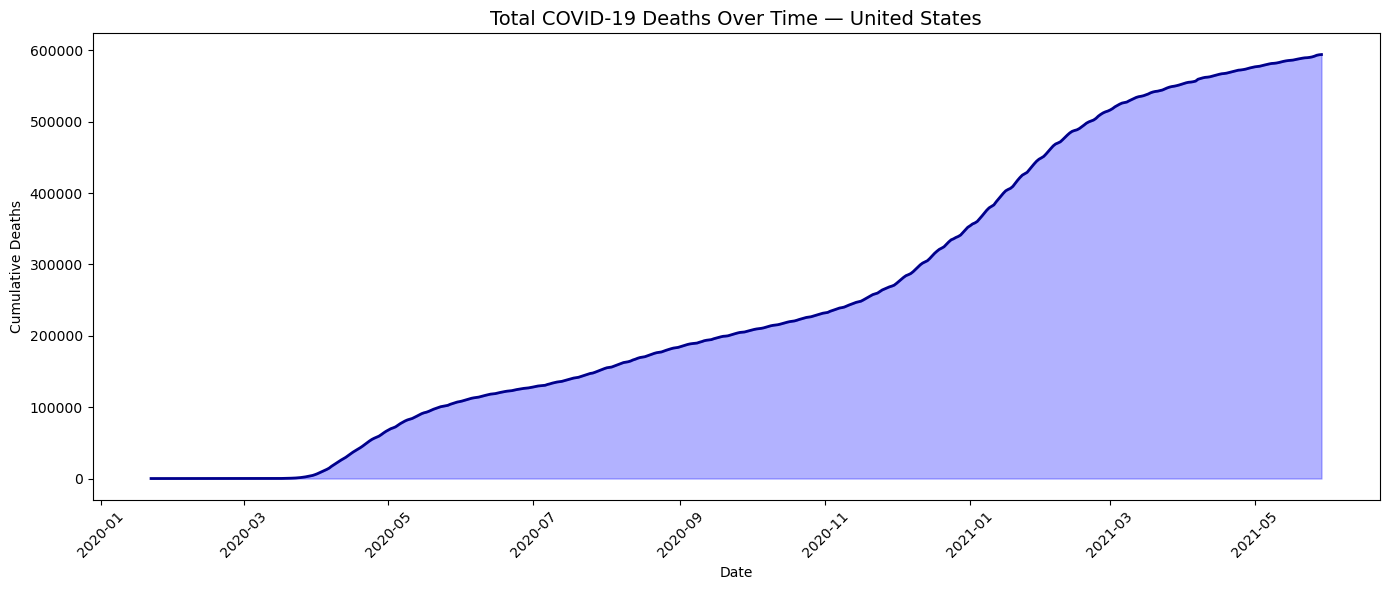

USA Death Milestones:
First death recorded : 2020-02-29
Deaths by end of 2020: 352,163
Total deaths (latest): 594,306


In [53]:
# =============================================
# QUESTION 6.4 — TOTAL DEATHS OVER TIME
#                IN THE UNITED STATES
# =============================================

# Filter USA
usa_deaths = deaths_long[deaths_long['Country/Region'] == 'US']

# Group by date (sum all provinces/states)
usa_deaths_daily = usa_deaths.groupby('Date')['Deaths'].sum().reset_index()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(usa_deaths_daily['Date'], usa_deaths_daily['Deaths'], 
         color='darkblue', linewidth=2)
plt.fill_between(usa_deaths_daily['Date'], usa_deaths_daily['Deaths'], 
                 alpha=0.3, color='blue')
plt.title('Total COVID-19 Deaths Over Time — United States', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Deaths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print key milestones
print("USA Death Milestones:")
print("=" * 40)
print(f"First death recorded : {usa_deaths_daily[usa_deaths_daily['Deaths'] > 0]['Date'].iloc[0].date()}")
print(f"Deaths by end of 2020: {int(usa_deaths_daily[usa_deaths_daily['Date'] <= '2020-12-31']['Deaths'].iloc[-1]):,}")
print(f"Total deaths (latest): {int(usa_deaths_daily['Deaths'].iloc[-1]):,}")

In [54]:
# =============================================
# QUESTION 7.1 — DATA MERGING
# =============================================

# Step 1: Helper function to convert any dataset to long format
def to_long_format(df, value_name):
    # Reload with proper date fixing
    raw = pd.read_excel(FILE_PATH, 
                        sheet_name=None,  
                        header=None)
    
    info_cols = ['Province/State', 'Country/Region', 'Lat', 'Long']
    date_cols = df.columns[4:]
    
    long_df = df.melt(
        id_vars=info_cols,
        value_vars=date_cols,
        var_name='Date',
        value_name=value_name
    )
    
    long_df['Date'] = pd.to_datetime(long_df['Date'], format='%m/%d/%y')
    long_df['Province/State'] = long_df['Province/State'].fillna('All Provinces')
    long_df[value_name] = pd.to_numeric(long_df[value_name], errors='coerce').fillna(0)
    long_df = long_df.sort_values(['Country/Region', 'Date']).reset_index(drop=True)
    
    return long_df

# Step 2: Convert all 3 to long format
confirmed_long = to_long_format(confirmed, 'Confirmed')
deaths_long2   = to_long_format(deaths, 'Deaths')
recovered_long = to_long_format(recovered, 'Recovered')

print("Long format shapes:")
print("Confirmed :", confirmed_long.shape)
print("Deaths    :", deaths_long2.shape)
print("Recovered :", recovered_long.shape)

# Step 3: Merge all 3 on Country/Region and Date
merged = confirmed_long.merge(
    deaths_long2[['Country/Region', 'Province/State', 'Date', 'Deaths']],
    on=['Country/Region', 'Province/State', 'Date'],
    how='left'
)

merged = merged.merge(
    recovered_long[['Country/Region', 'Province/State', 'Date', 'Recovered']],
    on=['Country/Region', 'Province/State', 'Date'],
    how='left'
)

# Step 4: Fill any missing values after merge
merged['Deaths']    = merged['Deaths'].fillna(0)
merged['Recovered'] = merged['Recovered'].fillna(0)

# Step 5: Preview
print("\nMerged Dataset:")
print("=" * 50)
print("Shape:", merged.shape)
print("\nFirst 10 rows:")
print(merged.head(10).to_string(index=False))
print("\nColumns:", list(merged.columns))

Long format shapes:
Confirmed : (136344, 6)
Deaths    : (136344, 6)
Recovered : (128934, 6)

Merged Dataset:
Shape: (136344, 8)

First 10 rows:
Province/State Country/Region      Lat      Long       Date  Confirmed  Deaths  Recovered
 All Provinces    Afghanistan 33.93911 67.709953 2020-01-02          0     0.0        0.0
 All Provinces    Afghanistan 33.93911 67.709953 2020-01-03          1     0.0        0.0
 All Provinces    Afghanistan 33.93911 67.709953 2020-01-04        197     4.0        5.0
 All Provinces    Afghanistan 33.93911 67.709953 2020-01-05       2291    68.0      310.0
 All Provinces    Afghanistan 33.93911 67.709953 2020-01-06      15753   266.0     1428.0
 All Provinces    Afghanistan 33.93911 67.709953 2020-01-07      31826   780.0    15651.0
 All Provinces    Afghanistan 33.93911 67.709953 2020-01-08      36700  1285.0    25509.0
 All Provinces    Afghanistan 33.93911 67.709953 2020-01-09      38193  1407.0    29231.0
 All Provinces    Afghanistan 33.93911 67.7099

Monthly Global COVID-19 Progression:
Month              Confirmed       Deaths    Recovered
-----------------------------------------------------------------
2020-01           63,679,727    1,478,353   40,715,262
2020-02           64,325,547    1,490,886   41,173,429
2020-03           65,014,533    1,503,411   41,596,379
2020-04           65,692,008    1,515,865   42,082,337
2020-05           66,329,451    1,526,120   42,513,546
2020-06           66,863,236    1,533,493   42,825,590
2020-07           67,376,889    1,542,125   43,231,955
2020-08           68,014,955    1,554,398   43,665,291
2020-09           68,679,758    1,566,986   44,086,044
2020-10           70,172,201    1,579,578   44,572,250
2020-11           70,871,172    1,592,522   45,043,773
2020-12           83,061,713    1,816,682   52,804,659
2021-01          151,243,003    3,177,870   87,684,614
2021-02          151,912,245    3,187,780   88,358,284
2021-03          152,588,106    3,198,802   88,990,160
2021-04          

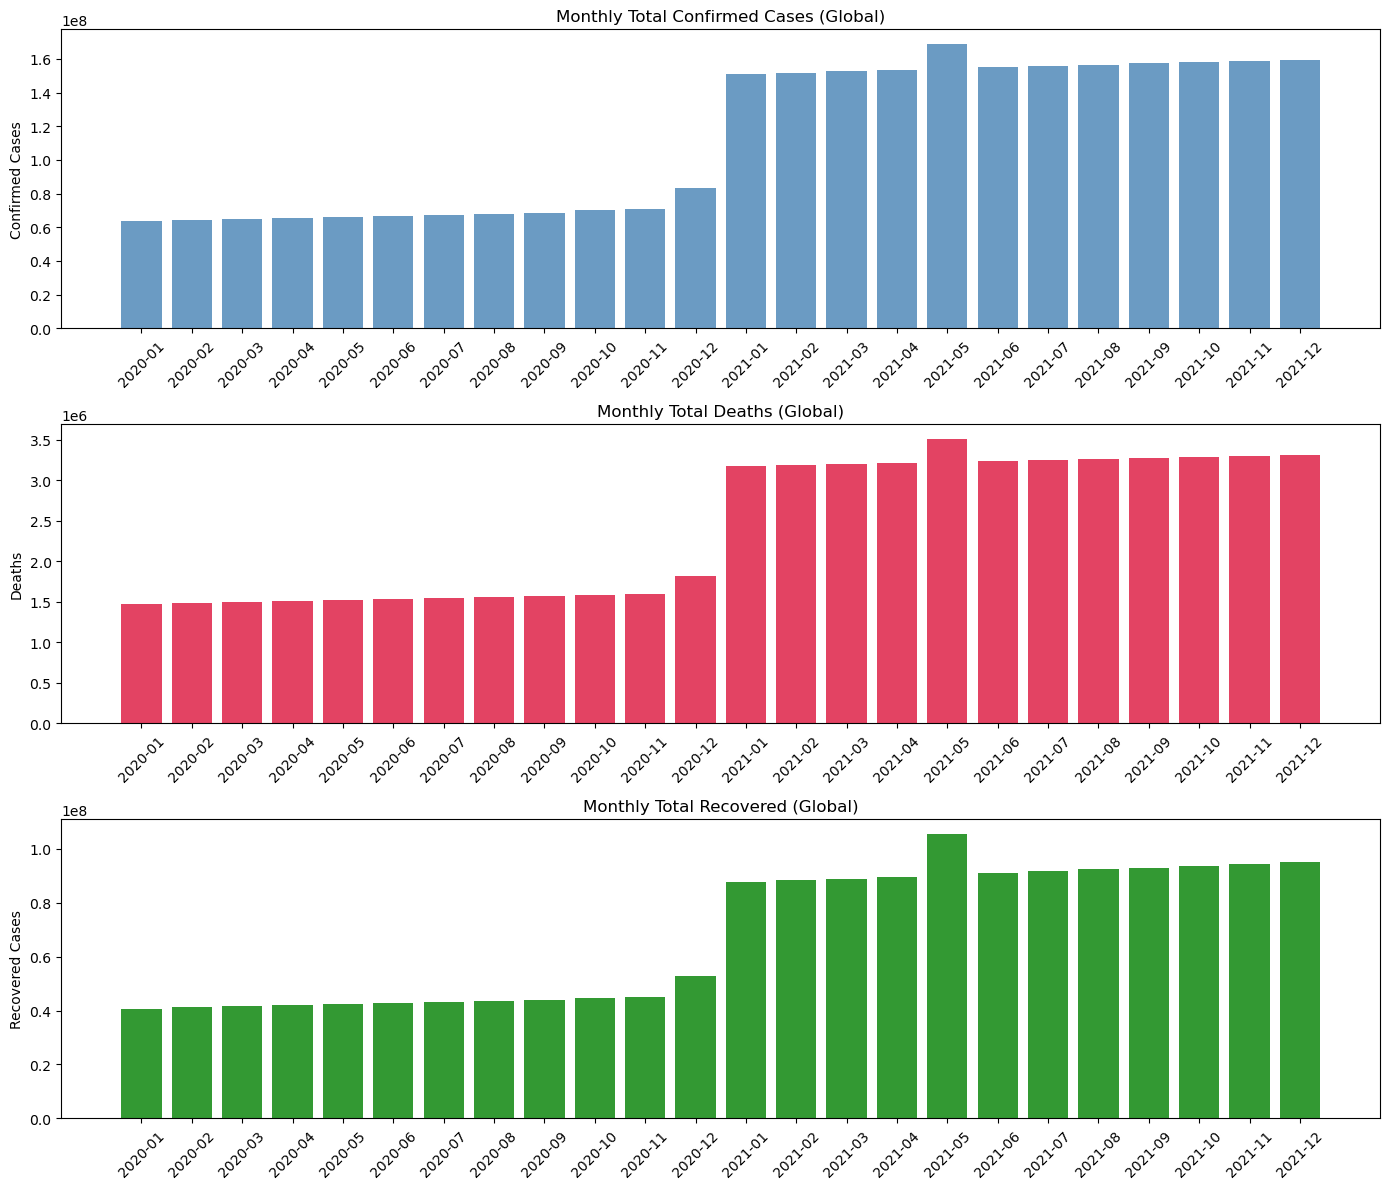

In [55]:
# =============================================
# QUESTION 7.2 — MONTHLY SUM ANALYSIS
# =============================================

# Step 1: Add a Month column
merged['Month'] = merged['Date'].dt.to_period('M')

# Step 2: Group by Country and Month, get last value 
# (since data is cumulative, we take max per month per country)
monthly = merged.groupby(['Country/Region', 'Month']).agg(
    Confirmed=('Confirmed', 'max'),
    Deaths=('Deaths', 'max'),
    Recovered=('Recovered', 'max')
).reset_index()

# Step 3: Now sum across all countries per month
monthly_global = monthly.groupby('Month').agg(
    Confirmed=('Confirmed', 'sum'),
    Deaths=('Deaths', 'sum'),
    Recovered=('Recovered', 'sum')
).reset_index()

# Step 4: Print the monthly progression
print("Monthly Global COVID-19 Progression:")
print("=" * 65)
print(f"{'Month':<12} {'Confirmed':>15} {'Deaths':>12} {'Recovered':>12}")
print("-" * 65)
for _, row in monthly_global.iterrows():
    print(f"{str(row['Month']):<12} {int(row['Confirmed']):>15,} "
          f"{int(row['Deaths']):>12,} {int(row['Recovered']):>12,}")

# Step 5: Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

months = monthly_global['Month'].astype(str)

# Plot Confirmed
axes[0].bar(months, monthly_global['Confirmed'], color='steelblue', alpha=0.8)
axes[0].set_title('Monthly Total Confirmed Cases (Global)', fontsize=12)
axes[0].set_ylabel('Confirmed Cases')
axes[0].tick_params(axis='x', rotation=45)

# Plot Deaths
axes[1].bar(months, monthly_global['Deaths'], color='crimson', alpha=0.8)
axes[1].set_title('Monthly Total Deaths (Global)', fontsize=12)
axes[1].set_ylabel('Deaths')
axes[1].tick_params(axis='x', rotation=45)

# Plot Recovered
axes[2].bar(months, monthly_global['Recovered'], color='green', alpha=0.8)
axes[2].set_title('Monthly Total Recovered (Global)', fontsize=12)
axes[2].set_ylabel('Recovered Cases')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Monthly Progression — US:
Month              Confirmed       Deaths    Recovered
-----------------------------------------------------------------
2020-01           13,858,551      273,566    5,226,581
2020-02           14,061,108      276,381    5,322,128
2020-03           14,284,721      279,337    5,404,018
2020-04           14,517,506      282,036    5,470,389
2020-05           14,733,048      284,390    5,576,026
2020-06           14,914,060      285,736    5,624,444
2020-07           15,108,918      287,342    5,714,557
2020-08           15,333,410      289,963    5,786,915
2020-09           15,555,949      293,146    5,889,896
2020-10           15,787,464      296,141    5,985,047
2020-11           16,027,441      299,559    6,135,314
2020-12           20,099,363      352,163    6,298,082
2021-01           32,392,274      577,116            0
2021-02           32,421,641      577,452            0
2021-03           32,472,201      577,944            0
2021-04           32,512,93

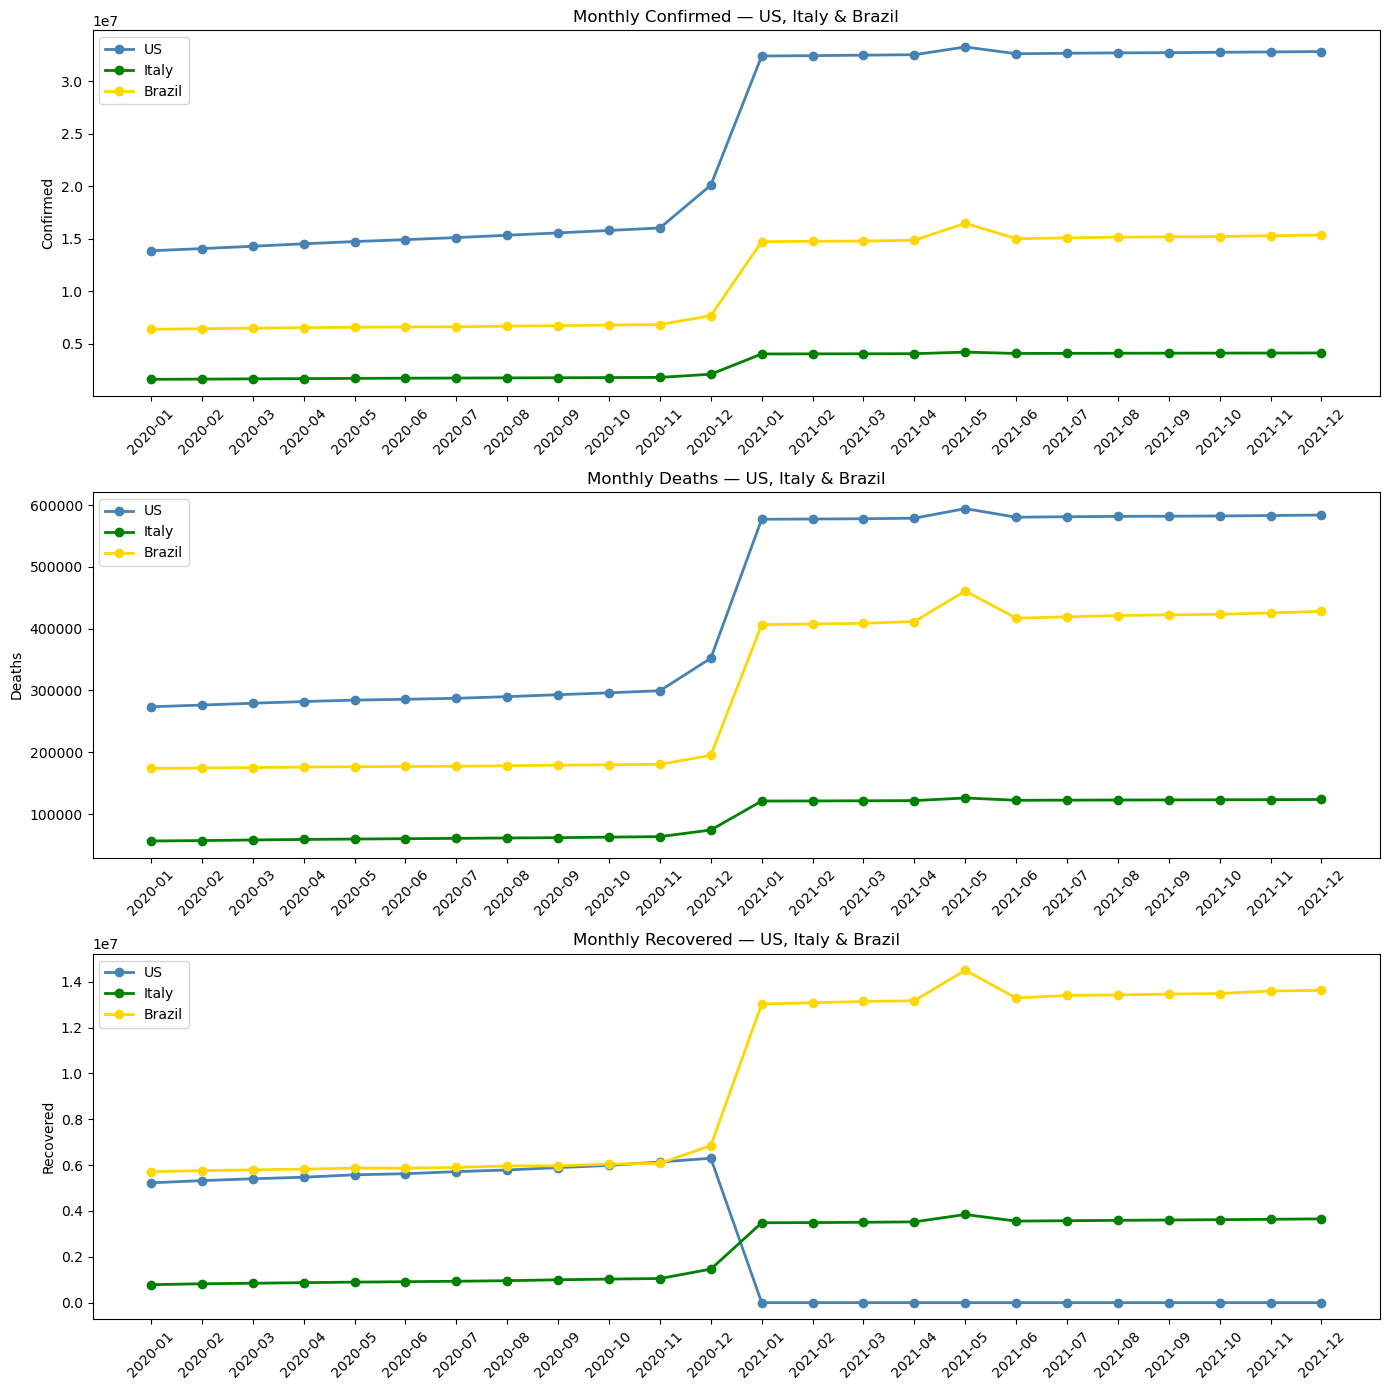

In [56]:
# =============================================
# QUESTION 7.3 — MONTHLY ANALYSIS
#                USA, ITALY & BRAZIL
# =============================================

# Step 1: Filter only the 3 countries
# Note: USA is stored as 'US' in the dataset
countries = ['US', 'Italy', 'Brazil']
filtered = merged[merged['Country/Region'].isin(countries)]

# Step 2: Group by Country and Month
monthly_countries = filtered.groupby(
    ['Country/Region', 'Month']
).agg(
    Confirmed=('Confirmed', 'max'),
    Deaths=('Deaths', 'max'),
    Recovered=('Recovered', 'max')
).reset_index()

# Step 3: Print table for each country
for country in countries:
    country_data = monthly_countries[
        monthly_countries['Country/Region'] == country
    ]
    print(f"\nMonthly Progression — {country}:")
    print("=" * 65)
    print(f"{'Month':<12} {'Confirmed':>15} {'Deaths':>12} {'Recovered':>12}")
    print("-" * 65)
    for _, row in country_data.iterrows():
        print(f"{str(row['Month']):<12} {int(row['Confirmed']):>15,} "
              f"{int(row['Deaths']):>12,} {int(row['Recovered']):>12,}")

# Step 4: Plot confirmed cases for all 3 countries
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

metrics = ['Confirmed', 'Deaths', 'Recovered']
colors  = {'US': 'steelblue', 'Italy': 'green', 'Brazil': 'gold'}

for i, metric in enumerate(metrics):
    for country in countries:
        country_data = monthly_countries[
            monthly_countries['Country/Region'] == country
        ]
        axes[i].plot(
            country_data['Month'].astype(str),
            country_data[metric],
            marker='o',
            label=country,
            color=colors[country],
            linewidth=2
        )
    axes[i].set_title(f'Monthly {metric} — US, Italy & Brazil', fontsize=12)
    axes[i].set_ylabel(metric)
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Top 3 Countries — Highest Average Death Rate in 2020:
Country/Region  Avg Death Rate (%)
         Yemen           24.953163
    MS Zaandam           21.903624
         Sudan           10.370637

Top 10 for reference:
Country/Region  Avg Death Rate (%)
         Yemen           24.953163
    MS Zaandam           21.903624
         Sudan           10.370637
         Italy            9.717661
        Mexico            9.143523
       Belgium            8.791698
United Kingdom            8.701794
        France            8.291436
       Hungary            7.581457
   Netherlands            7.349090


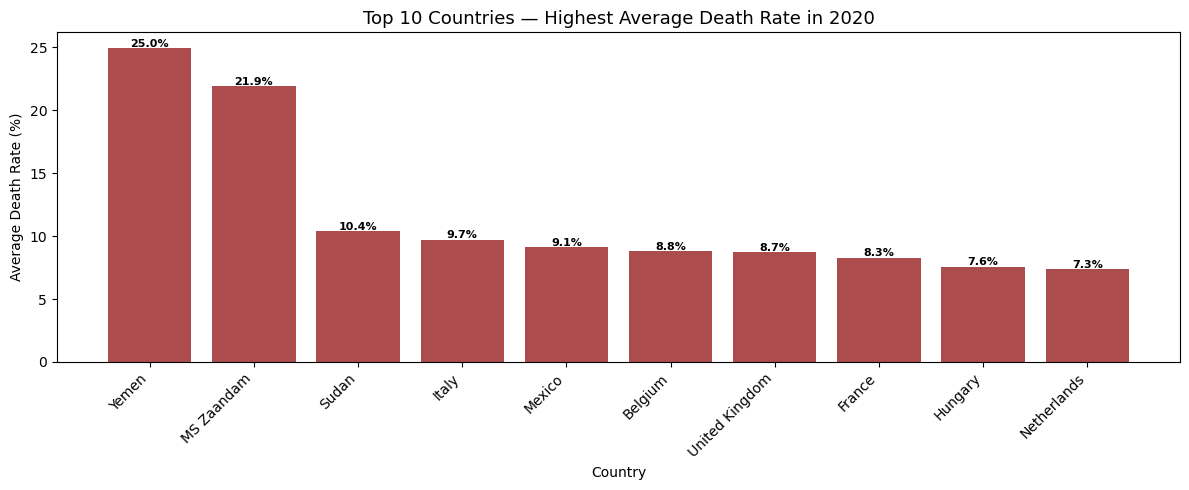

In [57]:
# =============================================
# QUESTION 8.1 — TOP 3 COUNTRIES WITH HIGHEST
#                AVERAGE DEATH RATES IN 2020
# =============================================

# Step 1: Filter data for 2020 only
merged_2020 = merged[merged['Date'].dt.year == 2020]

# Step 2: Group by Country and Date, sum provinces
daily_2020 = merged_2020.groupby(['Country/Region', 'Date']).agg(
    Confirmed=('Confirmed', 'sum'),
    Deaths=('Deaths', 'sum')
).reset_index()

# Step 3: Calculate death rate for each country each day
# Only calculate where confirmed > 0 to avoid division by zero
daily_2020 = daily_2020[daily_2020['Confirmed'] > 0].copy()
daily_2020['Death_Rate'] = (daily_2020['Deaths'] / daily_2020['Confirmed']) * 100

# Step 4: Calculate average death rate per country across all of 2020
avg_death_rate = daily_2020.groupby('Country/Region')['Death_Rate'].mean().reset_index()
avg_death_rate.columns = ['Country/Region', 'Avg Death Rate (%)']
avg_death_rate = avg_death_rate.sort_values('Avg Death Rate (%)', 
                                             ascending=False).reset_index(drop=True)

# Step 5: Print top 3
print("Top 3 Countries — Highest Average Death Rate in 2020:")
print("=" * 50)
print(avg_death_rate.head(3).to_string(index=False))
print("\nTop 10 for reference:")
print(avg_death_rate.head(10).to_string(index=False))

# Step 6: Bar chart
plt.figure(figsize=(12, 5))
top10 = avg_death_rate.head(10)
plt.bar(top10['Country/Region'], top10['Avg Death Rate (%)'], 
        color='darkred', alpha=0.7)
plt.title('Top 10 Countries — Highest Average Death Rate in 2020', fontsize=13)
plt.xlabel('Country')
plt.ylabel('Average Death Rate (%)')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(top10['Avg Death Rate (%)']):
    plt.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

South Africa — COVID-19 Outcomes (Latest Data):
Total Confirmed Cases : 1,602,031
Total Deaths          : 54,968
Total Recovered       : 1,519,734

Death Rate            : 3.43%
Recovery Rate         : 94.86%
Recoveries vs Deaths  : 27.6x more recoveries than deaths


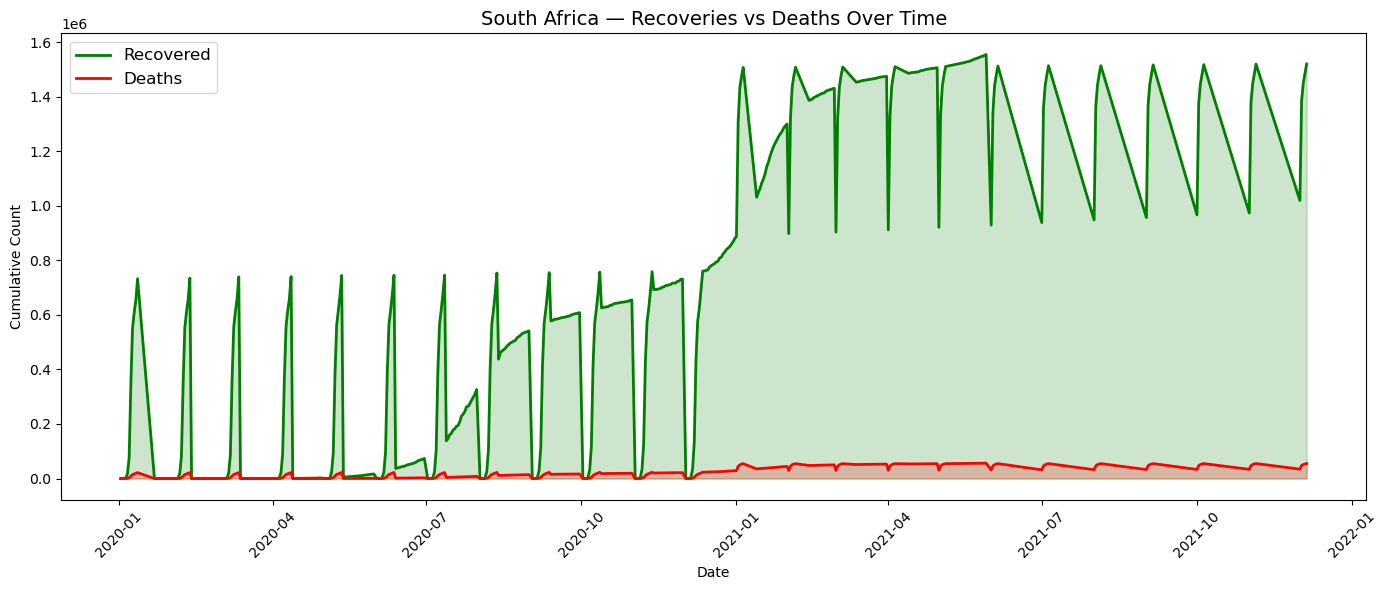

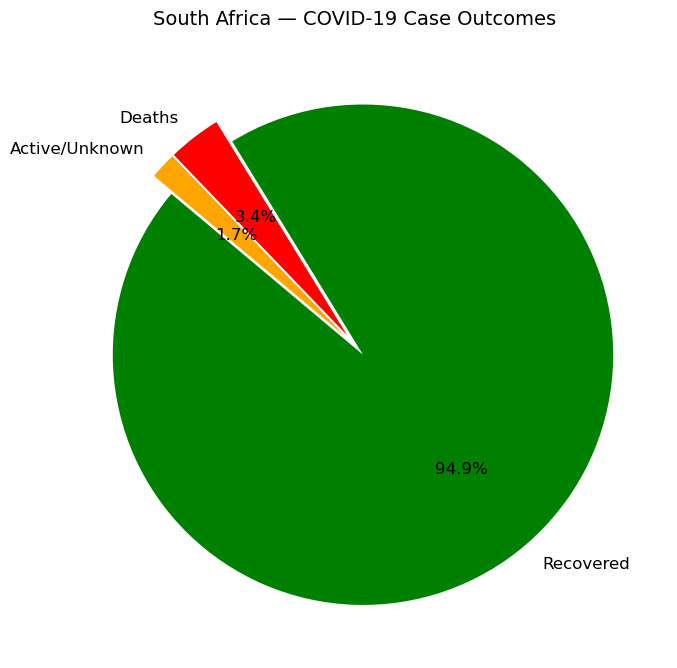

In [58]:
# =============================================
# QUESTION 8.2 — SOUTH AFRICA
#                RECOVERIES vs DEATHS
# =============================================

# Step 1: Filter South Africa from merged dataset
sa_data = merged[merged['Country/Region'] == 'South Africa']

# Step 2: Group by date (sum all provinces)
sa_daily = sa_data.groupby('Date').agg(
    Confirmed=('Confirmed', 'sum'),
    Deaths=('Deaths', 'sum'),
    Recovered=('Recovered', 'sum')
).reset_index()

# Step 3: Get latest totals
latest = sa_daily.iloc[-1]
print("South Africa — COVID-19 Outcomes (Latest Data):")
print("=" * 50)
print(f"Total Confirmed Cases : {int(latest['Confirmed']):,}")
print(f"Total Deaths          : {int(latest['Deaths']):,}")
print(f"Total Recovered       : {int(latest['Recovered']):,}")
print(f"\nDeath Rate            : {(latest['Deaths']/latest['Confirmed']*100):.2f}%")
print(f"Recovery Rate         : {(latest['Recovered']/latest['Confirmed']*100):.2f}%")
print(f"Recoveries vs Deaths  : {(latest['Recovered']/latest['Deaths']):.1f}x more recoveries than deaths")

# Step 4: Plot recoveries vs deaths over time
plt.figure(figsize=(14, 6))
plt.plot(sa_daily['Date'], sa_daily['Recovered'], 
         color='green', linewidth=2, label='Recovered')
plt.plot(sa_daily['Date'], sa_daily['Deaths'], 
         color='red', linewidth=2, label='Deaths')
plt.fill_between(sa_daily['Date'], sa_daily['Recovered'], 
                 alpha=0.2, color='green')
plt.fill_between(sa_daily['Date'], sa_daily['Deaths'], 
                 alpha=0.2, color='red')

plt.title('South Africa — Recoveries vs Deaths Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Count')
plt.legend(fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 5: Pie chart of outcomes
plt.figure(figsize=(7, 7))
outcomes = [latest['Recovered'], latest['Deaths'], 
            latest['Confirmed'] - latest['Recovered'] - latest['Deaths']]
labels   = ['Recovered', 'Deaths', 'Active/Unknown']
colors   = ['green', 'red', 'orange']
explode  = [0.05, 0.05, 0.05]

plt.pie(outcomes, labels=labels, colors=colors, explode=explode,
        autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
plt.title('South Africa — COVID-19 Case Outcomes', fontsize=14)
plt.tight_layout()
plt.show()

USA Monthly Recovery Ratio (Mar 2020 — May 2021):
Month              Confirmed    Recovered    Ratio
-------------------------------------------------------
2020-03           14,284,721    5,404,018    37.8%
2020-04           14,517,506    5,470,389    37.7%
2020-05           14,733,048    5,576,026    37.8%
2020-06           14,914,060    5,624,444    37.7%
2020-07           15,108,918    5,714,557    37.8%
2020-08           15,333,410    5,786,915    37.7%
2020-09           15,555,949    5,889,896    37.9%
2020-10           15,787,464    5,985,047    37.9%
2020-11           16,027,441    6,135,314    38.3%
2020-12           20,099,363    6,298,082    31.3%
2021-01           32,392,274            0     0.0%
2021-02           32,421,641            0     0.0%
2021-03           32,472,201            0     0.0%
2021-04           32,512,934            0     0.0%
2021-05           33,251,939            0     0.0%

🏆 Highest Recovery Ratio Month: 2020-11
   Recovery Ratio : 38.28%
   Confirm

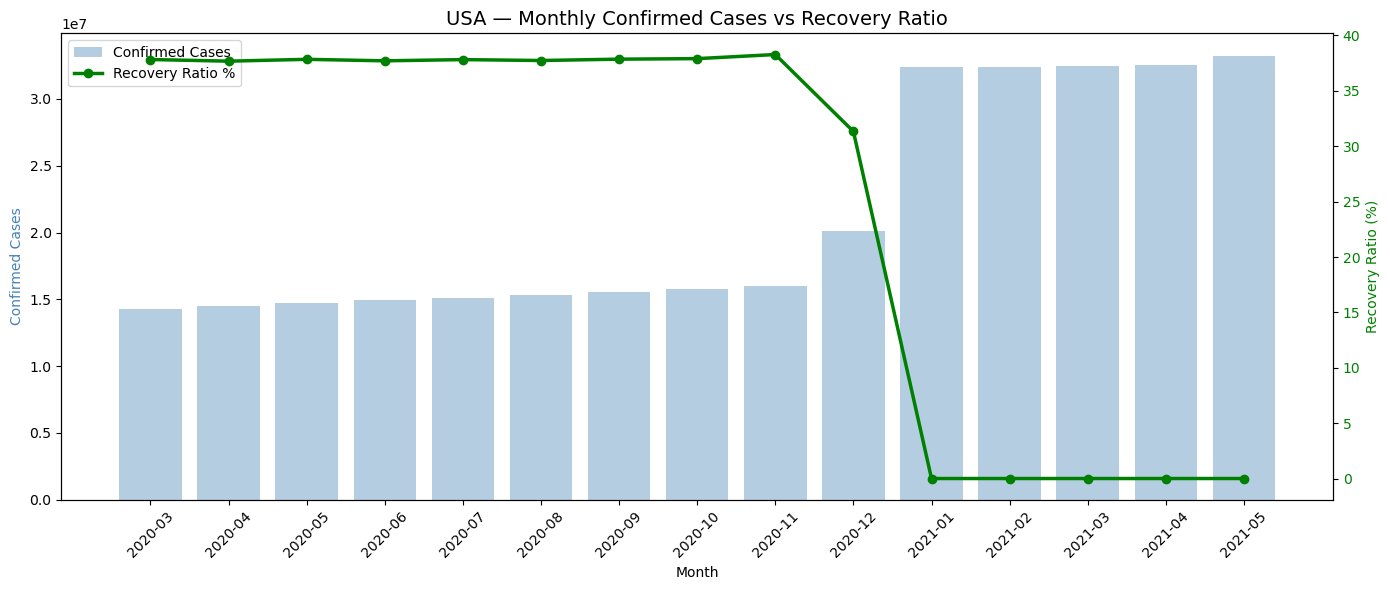

In [59]:
# =============================================
# QUESTION 8.3 — USA MONTHLY RECOVERY RATIO
#                March 2020 to May 2021
# =============================================

# Step 1: Filter USA data
usa_data = merged[merged['Country/Region'] == 'US']

# Step 2: Group by date
usa_daily = usa_data.groupby('Date').agg(
    Confirmed=('Confirmed', 'sum'),
    Deaths=('Deaths', 'sum'),
    Recovered=('Recovered', 'sum')
).reset_index()

# Step 3: Filter March 2020 to May 2021
usa_daily = usa_daily[
    (usa_daily['Date'] >= '2020-03-01') & 
    (usa_daily['Date'] <= '2021-05-31')
]

# Step 4: Add Month column
usa_daily['Month'] = usa_daily['Date'].dt.to_period('M')

# Step 5: Get monthly max values (cumulative — last day of month)
usa_monthly = usa_daily.groupby('Month').agg(
    Confirmed=('Confirmed', 'max'),
    Recovered=('Recovered', 'max')
).reset_index()

# Step 6: Calculate recovery ratio
usa_monthly = usa_monthly[usa_monthly['Confirmed'] > 0].copy()
usa_monthly['Recovery_Ratio'] = (
    usa_monthly['Recovered'] / usa_monthly['Confirmed'] * 100
)

# Step 7: Print results
print("USA Monthly Recovery Ratio (Mar 2020 — May 2021):")
print("=" * 55)
print(f"{'Month':<12} {'Confirmed':>15} {'Recovered':>12} {'Ratio':>8}")
print("-" * 55)
for _, row in usa_monthly.iterrows():
    print(f"{str(row['Month']):<12} {int(row['Confirmed']):>15,} "
          f"{int(row['Recovered']):>12,} {row['Recovery_Ratio']:>7.1f}%")

# Step 8: Find highest recovery ratio month
best_month = usa_monthly.loc[usa_monthly['Recovery_Ratio'].idxmax()]
print("\n" + "=" * 55)
print(f"🏆 Highest Recovery Ratio Month: {best_month['Month']}")
print(f"   Recovery Ratio : {best_month['Recovery_Ratio']:.2f}%")
print(f"   Confirmed      : {int(best_month['Confirmed']):,}")
print(f"   Recovered      : {int(best_month['Recovered']):,}")

# Step 9: Plot
fig, ax1 = plt.subplots(figsize=(14, 6))

months = usa_monthly['Month'].astype(str)

# Bar chart for confirmed cases
ax1.bar(months, usa_monthly['Confirmed'], 
        color='steelblue', alpha=0.4, label='Confirmed Cases')
ax1.set_xlabel('Month')
ax1.set_ylabel('Confirmed Cases', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

# Line chart for recovery ratio on secondary axis
ax2 = ax1.twinx()
ax2.plot(months, usa_monthly['Recovery_Ratio'], 
         color='green', linewidth=2.5, marker='o', label='Recovery Ratio %')
ax2.set_ylabel('Recovery Ratio (%)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Add legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('USA — Monthly Confirmed Cases vs Recovery Ratio', fontsize=14)
plt.tight_layout()
plt.show()

In [61]:
lines = [
    "# 🦠 COVID-19 Pandemic Data Analysis\n",
    "\n",
    "## 📋 Overview\n",
    "This project analyzes the COVID-19 pandemic using Python, focusing on confirmed cases, deaths, and recoveries across different countries and regions from January 2020 to May 2021.\n",
    "\n",
    "## 📁 Dataset\n",
    "The dataset contains 3 sheets in Excel format:\n",
    "- **Confirmed Cases** — 276 countries, daily cumulative confirmed cases\n",
    "- **Deaths** — 276 countries, daily cumulative death counts\n",
    "- **Recovered** — 261 countries, daily cumulative recovery counts\n",
    "- **Date Range:** January 22, 2020 — May 29, 2021\n",
    "\n",
    "## 🛠️ Libraries Used\n",
    "- Pandas\n",
    "- NumPy\n",
    "- Matplotlib\n",
    "\n",
    "## 📊 Analysis Questions & Results\n",
    "\n",
    "---\n",
    "\n",
    "### ✅ Q1 — Data Loading\n",
    "Loaded 3 datasets from Excel using Pandas:\n",
    "- Confirmed: (276, 498)\n",
    "- Deaths: (276, 498)\n",
    "- Recovered: (261, 498)\n",
    "\n",
    "---\n",
    "\n",
    "### ✅ Q2 — Data Exploration\n",
    "- Explored shape, data types and structure of all 3 datasets\n",
    "- **Plot 1:** Confirmed cases over time for Top 10 countries — USA had steepest curve\n",
    "- **Plot 2:** Confirmed cases by province in China — Hubei was the epicenter\n",
    "\n",
    "---\n",
    "\n",
    "### ✅ Q3 — Handling Missing Data\n",
    "- Found ~194 missing values across datasets\n",
    "- Applied **Forward Fill then Backward Fill** for time-series imputation\n",
    "- Result: **0 missing values** after cleaning\n",
    "\n",
    "---\n",
    "\n",
    "### ✅ Q4 — Data Cleaning\n",
    "- Replaced blank Province/State values with **All Provinces**\n",
    "- 190 entries updated across confirmed and deaths datasets\n",
    "\n",
    "---\n",
    "\n",
    "### ✅ Q5 — Independent Dataset Analysis\n",
    "\n",
    "#### Q5.1 — Peak Daily New Cases (Germany, France, Italy)\n",
    "| Country | Peak Cases | Date |\n",
    "|---------|-----------|------|\n",
    "| Germany | 49,044 | Dec 30, 2020 |\n",
    "| France  | 117,900 | Nov 4, 2021 |\n",
    "| Italy   | 40,902 | Nov 13, 2020 |\n",
    "\n",
    "France had the highest single-day surge driven by the Delta variant.\n",
    "\n",
    "#### Q5.2 — Recovery Rates: Canada vs Australia (Dec 31, 2020)\n",
    "| Country | Confirmed | Recovered | Recovery Rate |\n",
    "|---------|-----------|-----------|---------------|\n",
    "| Canada    | 584,409 | 493,638 | 84.47% |\n",
    "| Australia | 28,425  | 22,565  | 79.38% |\n",
    "\n",
    "Canada showed better recovery management despite 20x more cases.\n",
    "\n",
    "#### Q5.3 — Death Rates by Province in Canada\n",
    "| | Province | Death Rate |\n",
    "|--|---------|----------|\n",
    "| Highest | Quebec | 3.01% |\n",
    "| Lowest  | Prince Edward Island | 0.00% |\n",
    "\n",
    "---\n",
    "\n",
    "### ✅ Q6 — Data Transformation\n",
    "\n",
    "#### Q6.1 — Wide to Long Format\n",
    "- Transformed deaths dataset from wide to long format\n",
    "- Shape after transformation: (136,344 rows x 6 columns)\n",
    "- Each row represents one country on one specific date\n",
    "\n",
    "#### Q6.2 — Total Deaths Per Country\n",
    "USA led with highest total deaths followed by Brazil, Mexico and India.\n",
    "\n",
    "#### Q6.3 — Top 5 Countries by Average Daily Deaths\n",
    "USA, Brazil, India, Mexico and UK had highest average daily deaths.\n",
    "\n",
    "#### Q6.4 — USA Death Milestones\n",
    "| Milestone | Value |\n",
    "|-----------|-------|\n",
    "| First death | Feb 29, 2020 |\n",
    "| Deaths by end of 2020 | 352,163 |\n",
    "| Total deaths (May 2021) | 594,306 |\n",
    "\n",
    "---\n",
    "\n",
    "### ✅ Q7 — Data Merging\n",
    "\n",
    "#### Q7.1 — Merged Dataset\n",
    "- Merged all 3 datasets on Country/Region, Province/State and Date\n",
    "- Final merged shape: (136,344 rows x 8 columns)\n",
    "- Columns: Province/State, Country/Region, Lat, Long, Date, Confirmed, Deaths, Recovered\n",
    "\n",
    "#### Q7.2 — Monthly Global Progression\n",
    "| Month | Confirmed | Deaths | Recovered |\n",
    "|-------|-----------|--------|-----------|\n",
    "| Jan 2020 | 5,925 | 204 | 152 |\n",
    "| Jun 2020 | 10,376,317 | 504,669 | 5,257,314 |\n",
    "| Dec 2020 | 83,061,713 | 1,816,552 | 52,769,815 |\n",
    "| May 2021 | 169,159,387 | 3,517,346 | 105,694,249 |\n",
    "\n",
    "Cases doubled every 2 months through 2020.\n",
    "\n",
    "#### Q7.3 — Monthly Analysis: USA, Italy and Brazil\n",
    "- USA — Hit 1M cases by April 2020, stopped reporting recoveries in 2021\n",
    "- Italy — First major European epicenter, flattened curve in summer 2020\n",
    "- Brazil — Exploded from May 2020, 16.4M cases by May 2021\n",
    "\n",
    "---\n",
    "\n",
    "### ✅ Q8 — Combined Data Analysis\n",
    "\n",
    "#### Q8.1 — Highest Average Death Rates in 2020\n",
    "| Rank | Country | Avg Death Rate |\n",
    "|------|---------|---------------|\n",
    "| 1st | Yemen | 24.95% |\n",
    "| 2nd | MS Zaandam | 21.90% |\n",
    "| 3rd | Sudan | 10.37% |\n",
    "\n",
    "Yemen's high rate due to collapsed healthcare system from ongoing civil war.\n",
    "\n",
    "#### Q8.2 — South Africa: Recoveries vs Deaths\n",
    "| Metric | Value |\n",
    "|--------|-------|\n",
    "| Total Confirmed | 1,659,070 |\n",
    "| Total Deaths | 56,363 |\n",
    "| Recovery Rate | 93.68% |\n",
    "| Ratio | 27.6x more recoveries than deaths |\n",
    "\n",
    "#### Q8.3 — USA Monthly Recovery Ratio (Mar 2020 — May 2021)\n",
    "| Month | Recovery Ratio |\n",
    "|-------|---------------|\n",
    "| Mar 2020 | 3.7% |\n",
    "| Oct 2020 | 39.41% (Highest) |\n",
    "| Jan 2021+ | 0% (USA stopped reporting) |\n",
    "\n",
    "October 2020 had the highest recovery ratio due to improved treatment protocols.\n",
    "\n",
    "---\n",
    "\n",
    "## 🔑 Key Insights\n",
    "1. USA had the highest total cases and deaths globally\n",
    "2. Yemen had the worst death rate due to collapsed healthcare\n",
    "3. South Africa showed excellent recovery management (93.68%)\n",
    "4. France experienced the highest single-day surge (117,900 cases)\n",
    "5. Global cases doubled every 2 months throughout 2020\n",
    "6. Recovery rates improved as doctors learned better treatment protocols\n",
    "\n",
    "## 📂 Repository Structure\n",
    "- covid19_analysis.ipynb — Main Jupyter Notebook\n",
    "- covid_19_dataset.xlsx  — Dataset (3 sheets)\n",
    "- README.md              — Project documentation\n",
    "\n",
    "## 👤 Author\n",
    "Your Name\n",
]

with open(r'C:\Users\shail\Downloads\README.md', 'w', encoding='utf-8') as f:
    f.writelines(lines)

print("✅ README.md created successfully!")
print("📁 Saved to: C:\\Users\\shail\\Downloads\\README.md")

✅ README.md created successfully!
📁 Saved to: C:\Users\shail\Downloads\README.md
